Prepare data, build model

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, layers=3, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.layers = [nn.Linear(input_size, hidden_size),
                       nn.ReLU()]
        for _ in range(layers - 1):
            self.layers += [nn.Linear(hidden_size, hidden_size),
                            nn.ReLU()]
        self.layers += [nn.Linear(hidden_size, output_size)]
        self.model = nn.Sequential(*self.layers)
    
    def forward(self, x):
        x = x.flatten(start_dim=1) # flatten the 28x28 images to a vector of size 784
        return self.model(x)

# dataset gets downloaded to data/ and transformed to tensors
# MNIST is a basic handwritten digit dataset with 10 classes (0-9) and 28x28 pixel greyscale images
train_ds = datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor())
test_ds = datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor())

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=128)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleNN(28*28, 128, 10).to(device)


prepare training settings

In [2]:
model.train()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10


run training

In [3]:

# for tracking training history
train_loss_history = []
train_acc_history = []

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_dl:
        # prepare data
        images, labels = images.to(device), labels.to(device)
        images = images.view(-1, 28*28)

        # forward + backward + optimize
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # collect statistics
        running_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_loss_history.append(epoch_loss)
    train_acc_history.append(epoch_acc)
    print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Train-Accuracy: {epoch_acc:.4f}')


Epoch 1/10 | Loss: 0.3972 | Train-Accuracy: 0.8858
Epoch 2/10 | Loss: 0.1533 | Train-Accuracy: 0.9537
Epoch 3/10 | Loss: 0.1070 | Train-Accuracy: 0.9672
Epoch 4/10 | Loss: 0.0794 | Train-Accuracy: 0.9754
Epoch 5/10 | Loss: 0.0622 | Train-Accuracy: 0.9801
Epoch 6/10 | Loss: 0.0504 | Train-Accuracy: 0.9840
Epoch 7/10 | Loss: 0.0394 | Train-Accuracy: 0.9871
Epoch 8/10 | Loss: 0.0338 | Train-Accuracy: 0.9892
Epoch 9/10 | Loss: 0.0288 | Train-Accuracy: 0.9910
Epoch 10/10 | Loss: 0.0242 | Train-Accuracy: 0.9922


basic evaluation

In [4]:
test_preds = []
test_labels = []
test_data = []
model.eval()
with torch.no_grad():
    for images, labels in test_dl:
        images, labels = images.to(device), labels.to(device)
        images_flat = images.view(-1, 28*28)
        
        outputs = model(images_flat)
        
        test_preds.append(outputs)
        test_labels.append(labels)
        test_data.append(images_flat)

test_preds = torch.cat(test_preds, dim=0)
test_labels = torch.cat(test_labels, dim=0)
test_data = torch.cat(test_data, dim=0)

predicted_labels = test_preds.argmax(dim=1)
test_acc = (predicted_labels == test_labels).sum().item() / len(test_labels)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.9678


visualization of training history

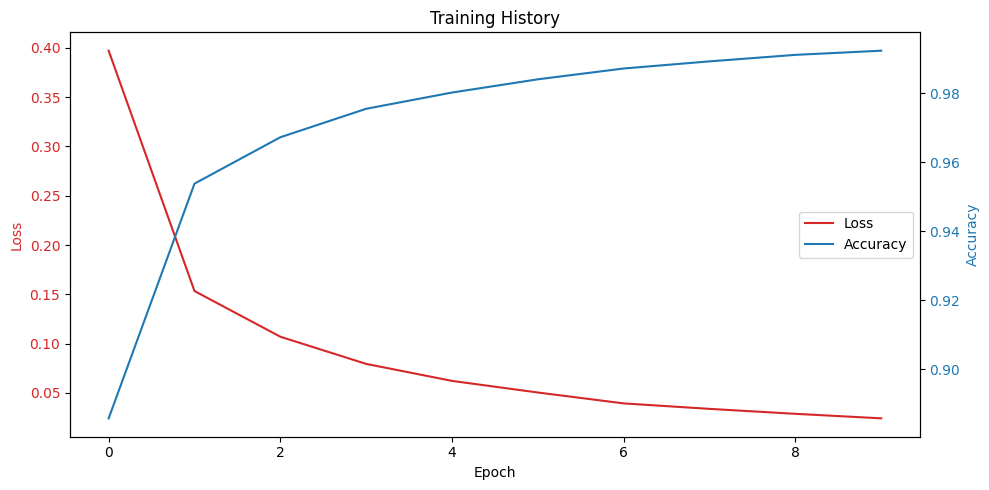

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# left Y-axis — loss
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(train_loss_history, color='tab:red', label='Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

# right Y-axis — accuracy
ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(train_acc_history, color='tab:blue', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# title and legend
plt.title('Training History')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.savefig('results/figures/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

basic adversarial attack

In [6]:
# basic adversarial attack that changes the pixels of a given input image in the direction of the gradient of the loss with respect to the input
# This way the image is changes so that the model is more likely to make a wrong prediction
# Epsilon controls how much the image is changed, a higher epsilon means a stronger attack
class Fast_Gradient_Sign_Method(nn.Module):
    def __init__(self, model, epsilon=0.1, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.model = model
        self.epsilon = epsilon
    
    def forward(self, x, y):
        # make the input require gradients
        x.requires_grad = True

        # forward pass
        outputs = self.model(x)
        loss = criterion(outputs, y)

        # backward pass
        self.model.zero_grad()
        loss.backward()

        # collect the sign of the gradients
        x_grad_sign = x.grad.sign()

        # create the adversarial example by adding the perturbation
        x_adv = x + self.epsilon * x_grad_sign

        return x_adv

run attack

In [7]:
fgsm = Fast_Gradient_Sign_Method(model, epsilon=0.1)
# create adversarial examples for the test set

test_adv = fgsm(test_data[:50], test_labels[:50])

with torch.no_grad():
    adv_predictions = model(test_adv)
    adv_pred_labels = adv_predictions.argmax(dim=1)

adv_acc = (adv_pred_labels == test_labels[:50]).sum().item() / 50
print(f'Adversarial Test Accuracy: {adv_acc:.4f}')


Adversarial Test Accuracy: 0.0200


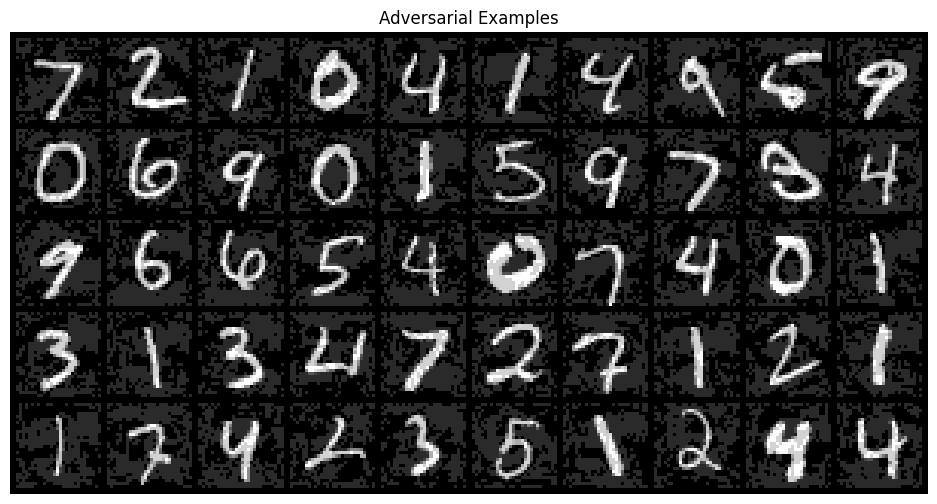

In [13]:
from torchvision.utils import make_grid

# reshape from [50, 784] back to [50, 1, 28, 28] for visualization
grid = make_grid(test_adv.view(-1, 1, 28, 28).cpu(), nrow=10, normalize=True)
plt.figure(figsize=(12, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.title('Adversarial Examples')
plt.axis('off')
plt.savefig('results/figures/adversarial_examples.png', dpi=150, bbox_inches='tight')
plt.show()

adjust attack

In [9]:
class Fast_Gradient_Sign_Method_Batch(nn.Module):
    def __init__(self, model, epsilon=0.1, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.model = model
        self.epsilon = epsilon
    
    def forward(self, testloader):
        all_adv = []

        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            
            # flatten images from [batch, 1, 28, 28] to [batch, 784]
            images_flat = images.view(-1, 28*28)
            images_flat.requires_grad = True

            # forward pass
            outputs = self.model(images_flat)
            loss = criterion(outputs, labels)

            # backward pass to get gradients w.r.t. input
            self.model.zero_grad()
            loss.backward()

            # apply FGSM perturbation
            x_grad_sign = images_flat.grad.sign()
            x_adv = images_flat + self.epsilon * x_grad_sign

            all_adv.append(x_adv.detach())

        # combine all batches into one tensor [10000, 784]
        test_adv_combined = torch.cat(all_adv, dim=0)

        return test_adv_combined


In [10]:
# the adjusted attack should work like this:

fsgm_batch = Fast_Gradient_Sign_Method_Batch(model, epsilon=0.1)
test_adv_batch = fsgm_batch(test_dl) # results in one big tensor, if you use the whole MNIST-testset, it should have the dimension [10000 x 28*28]

from torch.utils.data import TensorDataset
with torch.no_grad():
    adv_dataset = TensorDataset(test_adv_batch, test_labels)
    adv_dl = DataLoader(adv_dataset, batch_size=128)

    adv_predictions = []
    for adv_images, adv_labels in adv_dl:
        outputs = model(adv_images)
        adv_predictions.append(outputs)

adv_predictions = torch.cat(adv_predictions, dim=0)
adv_pred_labels = adv_predictions.argmax(dim=1)

adv_acc = (adv_pred_labels == test_labels).sum().item() / len(test_labels)
print(f'Adversarial Test Accuracy: {adv_acc:.4f}')


Adversarial Test Accuracy: 0.0807


You can try to experiment with the values of epsilon to see what changes are made to the data. You can experiment with different values and look at the resulting images and accuracies.

Epsilon: 0.00 | Accuracy: 0.9678
Epsilon: 0.01 | Accuracy: 0.8969
Epsilon: 0.05 | Accuracy: 0.2292
Epsilon: 0.10 | Accuracy: 0.0807
Epsilon: 0.15 | Accuracy: 0.0525
Epsilon: 0.20 | Accuracy: 0.0442
Epsilon: 0.25 | Accuracy: 0.0394
Epsilon: 0.30 | Accuracy: 0.0366


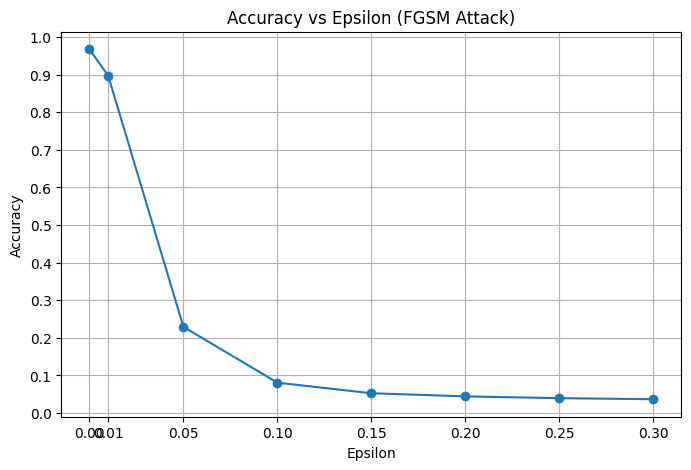

In [11]:
epsilons = [0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
adv_accuracies = []

for eps in epsilons:
    # run batch attack with current epsilon
    fgsm_eps = Fast_Gradient_Sign_Method_Batch(model, epsilon=eps)
    test_adv_eps = fgsm_eps(test_dl)

    # evaluate accuracy on adversarial examples
    adv_dataset_eps = TensorDataset(test_adv_eps, test_labels)
    adv_dl_eps = DataLoader(adv_dataset_eps, batch_size=128)

    correct = 0
    with torch.no_grad():
        for adv_images, adv_labels in adv_dl_eps:
            outputs = model(adv_images)
            preds = outputs.argmax(dim=1)
            correct += (preds == adv_labels).sum().item()

    adv_acc = correct / len(test_labels)
    adv_accuracies.append(adv_acc)
    print(f'Epsilon: {eps:.2f} | Accuracy: {adv_acc:.4f}')

# plot Accuracy vs Epsilon
plt.figure(figsize=(8, 5))
plt.plot(epsilons, adv_accuracies, 'o-', color='tab:blue')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon (FGSM Attack)')
plt.xticks(epsilons)
plt.yticks([i/10 for i in range(11)])
plt.grid(True)
plt.savefig('results/figures/accuracy_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()

the resulting plot should look like this:

![Epsilon curve](epsilon_sketch.png)